# 04 — Calibration and the neutral band

**Spec: §9.** Load-bearing, not cosmetic: two downstream components consume
probabilities directly (the neutral band below, and the aggregate estimator in
notebook 06). Thresholding uncalibrated scores would be meaningless.

Fit on the **calib half** of validation only.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION
import joblib
from datasets import load_dataset
from sklearn.metrics import accuracy_score

from src.predict import apply_temperature, label_from_prob

ds = load_dataset("tblard/allocine"); ds.pop("test")
Xva = [normalize(t) for t in ds["validation"]["review"]]
yva = np.array(ds["validation"]["label"])

calib_idx = np.load(REPO / "data" / "calib_idx.npy")
model = joblib.load(REPO / "data" / "model_tfidf.joblib")

Xc = [Xva[i] for i in calib_idx]; yc = yva[calib_idx]
d = model.decision_function(Xc)
logits = np.column_stack([np.zeros_like(d), d])   # softmax([0,d])[1]==sigmoid(d)
print(f"calibration set: {len(Xc):,}")

C:\Users\Windownet\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


calibration set: 10,000


In [2]:
def ece(probs, labels, n_bins=15):
    conf, pred = probs.max(1), probs.argmax(1)
    acc, bins, e = (pred == labels).astype(float), np.linspace(0, 1, n_bins+1), 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(e)

def nll(T):
    p = apply_temperature(logits, T)
    return -np.mean(np.log(np.clip(p[np.arange(len(yc)), yc], 1e-12, None)))

# Scalar grid search on log T -- one parameter, no need for LBFGS here, and a
# grid cannot diverge.
grid = np.exp(np.linspace(np.log(0.2), np.log(6.0), 400))
T = float(grid[np.argmin([nll(t) for t in grid])])

before, after = apply_temperature(logits, 1.0), apply_temperature(logits, T)
print(f"T = {T:.4f}")
print(f"ECE  {ece(before, yc):.4f} -> {ece(after, yc):.4f}")
print(f"NLL  {nll(1.0):.4f} -> {nll(T):.4f}")
print(f"accuracy unchanged: {accuracy_score(yc, before.argmax(1)):.4f} -> "
      f"{accuracy_score(yc, after.argmax(1)):.4f}  (temperature cannot move argmax)")

T = 0.6268
ECE  0.0545 -> 0.0077
NLL  0.2103 -> 0.1881
accuracy unchanged: 0.9280 -> 0.9280  (temperature cannot move argmax)


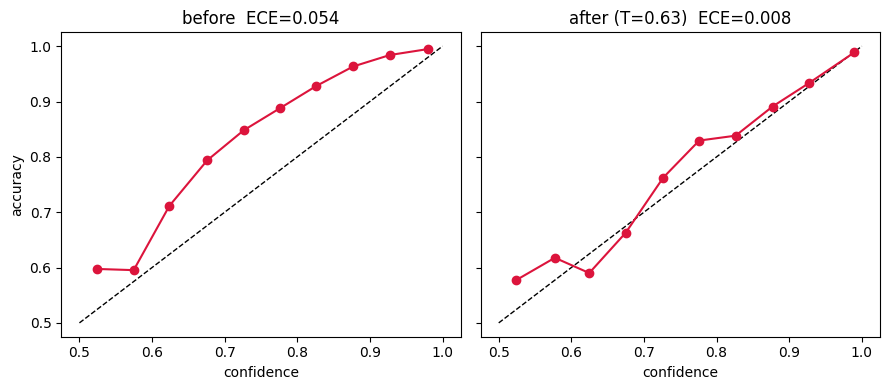

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, probs, name in ((axes[0], before, "before"), (axes[1], after, f"after (T={T:.2f})")):
    conf, pred = probs.max(1), probs.argmax(1)
    acc = (pred == yc).astype(float)
    bins = np.linspace(0.5, 1.0, 11)
    xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 20:
            xs.append(conf[m].mean()); ys.append(acc[m].mean())
    ax.plot([0.5, 1], [0.5, 1], "k--", lw=1, label="perfect")
    ax.plot(xs, ys, "o-", color="crimson")
    ax.set_title(f"{name}  ECE={ece(probs, yc):.3f}")
    ax.set_xlabel("confidence")
axes[0].set_ylabel("accuracy")
plt.tight_layout(); plt.savefig(REPO / "data" / "fig_calibration.png", dpi=120)
plt.show()

## The neutral band

Notebook 00 found that lukewarm reviews **are** present in the corpus, just
forced onto a side. The band only works if that produces genuine uncertainty
near p=0.5 rather than confident errors — so **verify it**, don't assume it.

Thresholds are set by a target abstention rate rather than by fitting on
3-class labels, because the 300-item real-feedback set (§6) does not exist
yet. **These are provisional.** Re-fit them once it does; that is the whole
point of building that set.

In [4]:
p_pos = apply_temperature(np.column_stack(
    [np.zeros_like(d), d]), T)[:, 1]

print(f"{'abstain':>8} {'theta_lo':>9} {'theta_hi':>9} {'acc on kept':>12} "
      f"{'acc on band':>12}")
rows = []
for rate in (0.05, 0.10, 0.15, 0.20):
    lo, hi = np.quantile(p_pos, [0.5 - rate/2, 0.5 + rate/2])
    band = (p_pos >= lo) & (p_pos <= hi)
    acc_kept = accuracy_score(yc[~band], (p_pos[~band] > 0.5).astype(int))
    acc_band = accuracy_score(yc[band], (p_pos[band] > 0.5).astype(int))
    rows.append((rate, lo, hi, acc_kept, acc_band))
    print(f"{rate:>8.0%} {lo:>9.4f} {hi:>9.4f} {acc_kept:>12.4f} {acc_band:>12.4f}")

 abstain  theta_lo  theta_hi  acc on kept  acc on band
      5%    0.3507    0.5973       0.9459       0.5880
     10%    0.2570    0.7093       0.9610       0.6310
     15%    0.1843    0.8032       0.9694       0.6933
     20%    0.1288    0.8582       0.9760       0.7360


**Read the two right-hand columns.** If accuracy inside the band is far
below accuracy outside it, the model is genuinely uncertain exactly where we
abstain — the band is doing real work and notebook 00's prediction holds. If
the two were similar, the band would be discarding good predictions and should
be narrowed or dropped.

In [5]:
RATE = 0.10
theta_lo, theta_hi = (float(x) for x in np.quantile(p_pos, [0.5 - RATE/2, 0.5 + RATE/2]))
band = (p_pos >= theta_lo) & (p_pos <= theta_hi)
acc_kept = accuracy_score(yc[~band], (p_pos[~band] > 0.5).astype(int))
acc_band = accuracy_score(yc[band], (p_pos[band] > 0.5).astype(int))

print(f"chosen: theta_lo={theta_lo:.4f} theta_hi={theta_hi:.4f} "
      f"(abstain {RATE:.0%})")
print(f"accuracy outside band {acc_kept:.4f} vs inside {acc_band:.4f} "
      f"-> gap {acc_kept - acc_band:+.4f}")
print()
print("Sample of what the band catches (genuinely mixed reviews?):")
raw = [ds["validation"]["review"][i] for i in calib_idx]
for i in np.flatnonzero(band)[:6]:
    print(f"  p={p_pos[i]:.3f} y={yc[i]} | {raw[i][:150]}")

chosen: theta_lo=0.2570 theta_hi=0.7093 (abstain 10%)
accuracy outside band 0.9610 vs inside 0.6310 -> gap +0.3300

Sample of what the band catches (genuinely mixed reviews?):


  p=0.495 y=0 | C'est quand je tombe sur un film comme ça que j'en viens presque à envier Gilbert Montagné...
  p=0.381 y=0 | Vraiment Allociné ? Vous laissez vraiment faire ça ? Vous êtes en train de vous plomber tout seul en laissant des manipulations aussi flagrantes des n
  p=0.492 y=0 | Comme j'ai dit poour le un j'ai perdu ma vie à regarder pokémon
  p=0.538 y=0 | Peut être le pire film d horreur que j ai vu de ma vie, au delà des mots, inqualifiable, une leçon en soit, abécédaire de tout ce qu il ne faut pas fa
  p=0.683 y=0 | Désobéissant aux ordres, le prince de Hombourg engage une charge de cavalerie menant son pays à la victoire. Mais pour avoir désobéi, il est enfermé e
  p=0.537 y=0 | Très déçue ... Je n'ai pas lu le livre ,et ce film m'a laissée complètement écoeurée de voir tant de personnes apprécier ce genre d'élucubrations auss


In [6]:
cfg_path = REPO / "inference_config.json"
cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
cfg.update(temperature=round(T, 4), theta_lo=round(theta_lo, 4),
           theta_hi=round(theta_hi, 4))
cfg_path.write_text(json.dumps(cfg, indent=2, ensure_ascii=False) + "\n",
                    encoding="utf-8")

json.dump({"temperature": round(T, 4),
           "ece_before": round(ece(before, yc), 4),
           "ece_after": round(ece(after, yc), 4),
           "theta_lo": round(theta_lo, 4), "theta_hi": round(theta_hi, 4),
           "abstain_rate": RATE,
           "acc_outside_band": round(float(acc_kept), 4),
           "acc_inside_band": round(float(acc_band), 4)},
          open(REPO / "data" / "results_calibration.json", "w"), indent=2)
print(cfg_path.read_text(encoding="utf-8"))

{
  "model_repo": "D:\\NLP Analyse de sentiment\\data\\model_tfidf.joblib",
  "revision": "local-tfidf-v1",
  "labels": [
    "négatif",
    "positif"
  ],
  "max_length": 288,
  "normalize_version": "v1",
  "temperature": 0.6268,
  "theta_lo": 0.257,
  "theta_hi": 0.7093,
  "tpr": 0.9631,
  "fpr": 0.0426,
  "backend": "sklearn"
}

